In [2]:
from utils import * 
import subprocess
import json 
import glob
from msa import msa_main
from files.rnafold import RNAFoldOutput
import networkx as nx
from ppi import * 

%load_ext autoreload 
%autoreload 2

In [3]:
genes_df = pd.read_csv('../data/genes/genes.csv', index_col=0)
genes_df['cluster_id'] = genes_df.index.map(json.load(open('../data/genes/clusters.json', 'r')))
genes_df = genes_df[(genes_df.cluster_id == 25)].copy()
genes_df['gc_content'] = genes_df.nt_seq.apply(get_gc_content)

FASTAFile.from_df(genes_df).write('../data/genes/cluster_25.faa')
if not os.path.exists('../data/genes/cluster_25.afa'):
    subprocess.run('muscle -align ../data/genes/cluster_25.faa -output ../data/genes/cluster_25.afa', shell=True, check=True)

msa = MSAFile.from_file('../data/genes/cluster_25.afa')

for row in genes_df.itertuples():
    print(f'{row.Index} ({row.start}-{row.stop}) {row.gc_content * 100:.1f}% GC {row.seq}')

print('\nMinimum cluster_25 gene length:', genes_df.seq.apply(len).min())
print('Maximum cluster_25 gene length:', genes_df.seq.apply(len).max())

orfm.bz_0.1_70 (14445-14882) 35.3% GC MTETKDRMTDFKIGIKQSEPFEIPEMDDGVYNAKLIDIELRVDIPDGKGGKFDKLNWNFDIDGKKIISQSSTTISNLSKAFGWIKALTGKEPEIGKDFSPSSVNGKSCQVIIKHRAVVLNTETVQMPYVSDVLPVKKSK
orfm.bz_2.1_138 (13260-13719) 30.0% GC MTENQEIENFQVDVKESKPFEYPEIDDGEYNAILKKVTLKAGIENKQHEKFDLMTWYFDVDGKEIKGTSSAKITTMSKAYGWIKSITGIEPEINKPFIPSSLKDSKCRIIVKNEDEVRDFQGTKTTMHKPIVIEVMHTKTKK
orfm.bz_11.1_159 (14663-15131) 33.3% GC MKYKMTENKEPMKNFTIGITESKKFEIPEIKDGVYDAVLKDMELKVGLPDGKGGAFDMIQWNFDVDGKEIAGKTSTIISTLSKAYIWITALTGAEPEKDKDFQPVSVMGNKCQVIIKHQKKIREFNHERQTLNLPYIHDVLPAK

Minimum cluster_25 gene length: 139
Maximum cluster_25 gene length: 144


In [72]:
# Based on filamentous phage literature, it seems likely that there should be cluster_25 homologs in all of the genomes. 
# However, there might be substantial sequence divergence, so am approaching this by looking for other proteins with OB-fold annotations. 

foldseek_search_df = pd.concat([pd.read_csv(path, sep='\t', names=FOLDSEEK_FIELDS).assign(path=path) for path in glob.glob('../data/genes/foldseek/genes*')])
foldseek_search_df['genome_id'] = foldseek_search_df.query_id.apply(get_genome_id)

filters = dict()
filters['low_tm_score'] = foldseek_search_df.alignment_tm_score < 0.5
filters['short_alignment'] = foldseek_search_df.alignment_length < 50
filters['bz_12_gene'] = foldseek_search_df.genome_id == 'bz_12'

foldseek_search_df = apply_filters(filters, foldseek_search_df)

apply_filters: 263870 entries removed by low_tm_score.
apply_filters: 79859 entries removed by short_alignment.
apply_filters: 41792 entries removed by bz_12_gene.


In [163]:
# include_terms = ['DUF669', 'ssDNA', 'OB-fold', 'DNA-binding', 'DNA binding', 'single-stranded', 'single stranded']
include_terms = ['DUF669', 'ssDNA', 'OB-fold', 'single-stranded', 'single stranded']
exclude_terms = ['Winged helix', 'HTH', 'Bacteriophage T5 Orf172', '8j86-assembly1_A']

filter_ = foldseek_search_df.target_header.str.contains( '|'.join(include_terms), case=False) & ~foldseek_search_df.target_header.str.contains( '|'.join(exclude_terms))
print('Number of genomes with a potential ssDNA-binding protein:', foldseek_search_df[filter_].genome_id.nunique())

Number of genomes with a potential ssDNA-binding protein: 11


In [164]:
df = pd.read_csv('../data/genes/genes.csv', index_col=0)
df['cluster_id'] = df.index.map(json.load(open('../data/genes/clusters.json', 'r')))
df['length'] = df.seq.apply(len)
print(df.loc['orfm.bz_7.1_37'].seq)

filters = dict()
filters['no_ssdna_binding_hit'] = ~df.index.isin(foldseek_search_df[filter_].query_id.unique()) & (df.cluster_id != 12)
filters['longer_than_200_aa'] = (df.length_from_start_codon > 200)
filters['shorter_than_85_aa'] = (df.length_from_start_codon < 85) # the filamentous phage equivalent is 97 aa.
filters['cluster_already_characterized'] = df.cluster_id.isin([0, 7, 3, 8, 20, 2])
filters['not_supported_by_prodigal'] = df.prodigal_gene_id.isnull()

# Even though cluster_12 does not have many Foldseek hits, the length and genome positions are correct, and examination of the structure
# prediction indicates that it does look similar (not sure why the structure is so low-confidence). 
# Furthermore, some of the cluster_12 proteins specifically have hits for p5 (1ae3-assembly1_A-2 MUTANT R82C OF GENE V PROTEIN)
genome_ids_with_cluster_12 = df[df.cluster_id == 12].genome_id.unique().tolist()
genome_ids_with_cluster_25 = df[df.cluster_id == 25].genome_id.unique().tolist()
filters['redundant_ssdna_binding_protein'] = (df.genome_id.isin(genome_ids_with_cluster_12 + genome_ids_with_cluster_25)) & ~(df.cluster_id.isin([12, 25]))

exclude_gene_ids = ['orfm.bz_11.1_179', 'orfm.bz_11.1_173', 'orfm.bz_11.1_45'] # Weak hits, and bz_11 already has a cluster_25 protein.
exclude_gene_ids += ['orfm.bz_10.1_72', 'orfm.bz_9.1_111'] # Foldseek hits indicate Ig-like fold.
exclude_gene_ids += ['orfm.bz_7.1_95'] # None of the ssDNA binding hits are for proteins that make sense; probably has some nucleotide-binding activity. 
exclude_gene_ids += ['orfm.bz_7.1_44'] # Very high-confidence structure that looks completely wrong, no convincing ssDNA-binding Foldseek hits.
exclude_gene_ids += ['orfm.bz_7.1_149'] # Structure and Foldseek hits do not make sense. 
exclude_gene_ids += ['orfm.bz_4.1_174'] # Too short and the structure looks wrong. 
filters['manually_removed'] = df.index.isin(exclude_gene_ids)
# 
df = apply_filters(filters, df)
print('Number of genomes with a potential ssDNA-binding protein:', df.genome_id.nunique())

# All genomes except bz_7 have a hit whose structure and placement kind of make sense, and nominally have ssDNA binding activity (if not specific annotations
# for an OB-fold). I manually went through potential bz_7 proteins, and didn't see any obvious candidates, but it is possible that structure prediction failed. 

# I also don't really know if I trust the bz_4 hit at all, it seems possibly too short, and hits are for RecJ (though RecJ has something that looks like an OB-fold).

# Tried to identify another ssDNA binding protein in bz_7 (filtering only based on length) to no avail. 

# orfm.bz_7.1_5 is completely disordered, no structure whatsoever. 
# orfm.bz_7.1_44 has a weak structure, but doesn't look right. 
# orfm.bz_7.1_56 is three alpha helices.
# orfm.bz_7.1_95 also does not look right. 
# orfm.bz_7.1_37? Could be, but disrupted by one of bz_7's repeat regions. 

MCNGIAVLVYLKNGELKGLCTGISSHDELCKQDEELRYGKIEPYRFELLYPCNLIFDRVYNMDKGVGVANEQPEQAIWDEAFRVAKPYFIKHTKEQLQYAHLTHANLTSADLRYANLTGADLTDADLTDADLTGANLTDADIRHVNLTDAVLTGAVLTGADLRYANLTDADLTDADLTDADFTGANLTDADLRYAYHTDTQKKQAEINEGRF
apply_filters: 1529 entries removed by no_ssdna_binding_hit.
apply_filters: 85 entries removed by longer_than_200_aa.
apply_filters: 1359 entries removed by shorter_than_85_aa.
apply_filters: 55 entries removed by cluster_already_characterized.
apply_filters: 1204 entries removed by not_supported_by_prodigal.
apply_filters: 1224 entries removed by redundant_ssdna_binding_protein.
apply_filters: 9 entries removed by manually_removed.
Number of genomes with a potential ssDNA-binding protein: 10


In [ ]:
# Write the processed sequences to a FASTA file for alignment. 

database_df = df.copy()
database_path = '../data/genes/cluster_25.faa'
name = 'cluster_25'

FASTAFile.from_df(database_df.assign(seq=database_df.seq, description='')).write(database_path)
msa_main(database_path, query_gene_ids=df.index.tolist(), fmt='afa', name=name, output_dir='../data/genes/muscle', min_coverage=0.9)

# Also generate MSAs in the correct format for AlphaFold.
msa_paths = msa_main(database_path, query_gene_ids=df.index.tolist(), fmt='a3m', name=name, database_dir='../data/genes/mmseqs/db/', output_dir='../data/genes/mmseqs', min_coverage=0.5, sensitivity=10)

msa_dereplicate: min_coverage = 0.9
msa_dereplicate: min_seq_identity = 0.95
msa_dereplicate: coverage_mode = 5
msa_dereplicate: 10 representative sequences when clustered at 0.95 minimum identity.
msa_build_afa: muscle -align /home/prichter/Documents/banfield/betazoid/data/genes/muscle/cluster_25_reps.faa -output /home/prichter/Documents/banfield/betazoid/data/genes/muscle/cluster_25.afa
msa_build_afa: clipkit /home/prichter/Documents/banfield/betazoid/data/genes/muscle/cluster_25.afa -o /home/prichter/Documents/banfield/betazoid/data/genes/muscle/cluster_25.trimmed.afa -g 0.8 --log
msa_dereplicate: min_coverage = 0.4
msa_dereplicate: min_seq_identity = 0.95
msa_dereplicate: coverage_mode = 5
msa_dereplicate: 10 representative sequences when clustered at 0.95 minimum identity.
msa_build_a3m: num_iterations = 1
msa_build_a3m: sensitivity = 10
msa_build_a3m: mmseqs createdb ../data/genes/mmseqs/cluster_25_reps.faa ../data/genes/mmseqs/db/database
msa_build_a3m: mmseqs search ../data/gen

In [157]:
num_subunits = 1

inputs = list()
for path in msa_paths:
    with open(path, 'r') as f:
        msa = f.read()
        print(f'Number of sequences in {path}:', msa.count('>'))

        gene_id = os.path.basename(path).replace('.a3m', '')
        input = AlphaFoldInputFile(name=f'{get_genome_id(gene_id)}_cluster_20_{num_subunits}mer_processed', num_seeds=1, dialect='alphafoldserver')
        input.add_seq(database_df.loc[gene_id, 'seq'], unpaired_msa=msa, paired_msa="", n=num_subunits)
        inputs.append(input)

inputs = [input.get_info() for input in inputs]
with open('/home/prichter/Downloads/cluster_25.json', 'w') as f:
    json.dump(inputs, f)

Number of sequences in ../data/genes/mmseqs/orfm.bz_0.1_70.a3m: 3
Number of sequences in ../data/genes/mmseqs/orfm.bz_11.1_159.a3m: 3
Number of sequences in ../data/genes/mmseqs/orfm.bz_5.1_42.a3m: 6
Number of sequences in ../data/genes/mmseqs/orfm.bz_2.1_138.a3m: 3
Number of sequences in ../data/genes/mmseqs/orfm.bz_4.1_35.a3m: 1
Number of sequences in ../data/genes/mmseqs/orfm.bz_10.1_120.a3m: 6
Number of sequences in ../data/genes/mmseqs/orfm.bz_3.1_155.a3m: 6
Number of sequences in ../data/genes/mmseqs/orfm.bz_9.1_158.a3m: 6
Number of sequences in ../data/genes/mmseqs/orfm.bz_8.1_87.a3m: 6
Number of sequences in ../data/genes/mmseqs/orfm.bz_1.1_30.a3m: 6


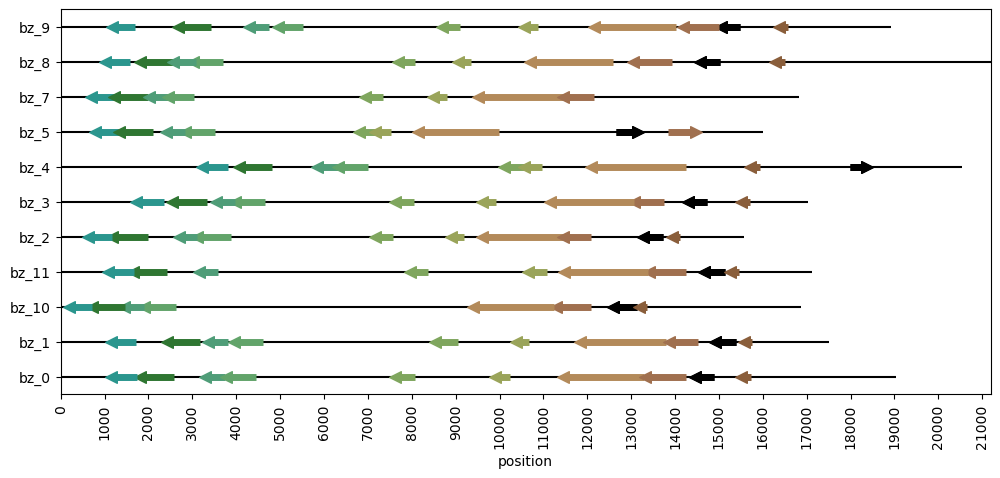

In [158]:
cluster_ids = df.cluster_id.values.tolist() + [8, 7, 0, 4, 5, 6, 1, 3, 2]

colors = ['#8A5E3B', '#A0704F', '#B38A5A', '#9AA45A', '#7FA65E', '#62A46A', '#4F9D78', "#2F7632", "#2B968E", "#5691D8", "#323986"]

palette = dict(zip([8, 7, 0, 4, 5, 6, 1, 3, 2], colors))

fig, ax = plt.subplots(figsize=(12, 5))

figure_df = df.copy()
figure_df = pd.concat([figure_df, pd.read_csv('../data/genes/genes.csv', index_col=0)])
figure_df['cluster_id'] = figure_df.index.map(json.load(open('../data/genes/clusters.json', 'r')))
figure_df['gene_id'] = figure_df.index
figure_df = figure_df[figure_df.cluster_id.isin(cluster_ids)].copy()

plot_orfs(figure_df, ax=ax, palette=palette)



In [3]:
colabfold_metadata_df = pd.read_csv('analysis-1-structs_colabfold_metadata.csv')
colabfold_metadata_df = colabfold_metadata_df[colabfold_metadata_df.name.isin(genes_df.index)].copy()
# colabfold_metadata_df
# The pTMs for this cluster are already quite good, so I don't think an MSA is necessary. 

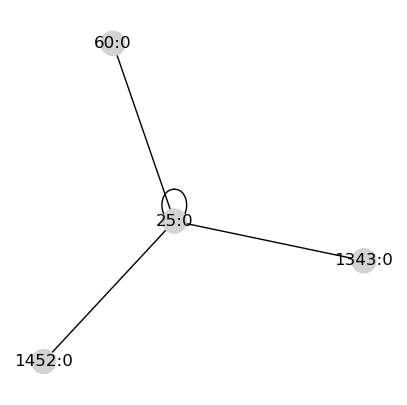

In [4]:
# First, I want to check for any potential contacts in the bz_0 genome. Interestingly, it seems as though the strongest interaction signal is homodimerization. 

contacts_df = pd.read_csv('analysis-1-ppi-bz_0_contacts.csv')
contacts_df = contacts_df[contacts_df.name.str.contains('bz_0.1_70')].copy()
contacts_df = contacts_df.sort_values('contact_prob', ascending=False).drop_duplicates('name')
contacts_df['gene_id_0'] = contacts_df.name.str.split('-').str[0]
contacts_df['gene_id_1'] = contacts_df.name.str.split('-').str[1]
contacts_df['cluster_id_0'] = contacts_df.gene_id_0.map(json.load(open('../data/genes/clusters.json', 'r')))
contacts_df['cluster_id_1'] = contacts_df.gene_id_1.map(json.load(open('../data/genes/clusters.json', 'r')))
contacts_df = contacts_df[(contacts_df.cluster_id_0 == 25) | (contacts_df.cluster_id_1 == 25)].copy()

def get_contact_id(row):
    '''Construct a contact_id from a contact_df entry. These IDs are of the form {node_type}:{position}. The contact IDs are necessarily order-invariant; 
    in other words, the contact ID for an edge (u, v) must be the same ad the contact ID for (v, u).'''
    contact_id = sorted([f'{int(row.cluster_id_0)}:0', f'{int(row.cluster_id_1)}:0'])
    return '-'.join(contact_id)

contacts_df['contact_id'] = contacts_df.apply(get_contact_id, axis=1)

fig, ax = plt.subplots(figsize=(5, 5))
graph = get_contact_graph(contacts_df, min_num_models=0, min_contact_prob=0)
plot_contact_graph(graph, pos=nx.spring_layout(graph, k=0.3), ax=ax)



In [5]:
foldseek_search_df = pd.concat([pd.read_csv(path, sep='\t', names=FOLDSEEK_FIELDS).assign(path=path) for path in glob.glob('../data/genes/foldseek/genes*')])
foldseek_search_df = foldseek_search_df[foldseek_search_df.query_id.isin(genes_df.index)]

filters = dict()
filters['low_tm_score'] = foldseek_search_df.alignment_tm_score < 0.7
filters['short_alignment'] = foldseek_search_df.alignment_length < 50

foldseek_search_df = apply_filters(filters, foldseek_search_df)


apply_filters: 7440 entries removed by low_tm_score.
apply_filters: 62 entries removed by short_alignment.


In [6]:
uncharacterized_ids = ['A0A8S5V5T3', 'A0A482MGF2', 'D6PGE1', 'A0A8S5LCJ6', 'A0A5Q2W7C5', 'A0A6J5S277']

categories = dict()
categories['uncharacterized'] = foldseek_search_df.target_header.str.contains('uncharacterized', case=False) | foldseek_search_df.target_header.isin(uncharacterized_ids)
categories['DUF669 domain-containing protein'] = foldseek_search_df.target_header.str.contains('DUF669') 
categories['DUF5666 domain-containing protein'] = foldseek_search_df.target_header.str.contains('DUF5666') # https://www.ncbi.nlm.nih.gov/Structure/cdd/pfam18914, OB-like fold, which is involved in DNA binding.
categories['DNA-binding protein'] = foldseek_search_df.target_header.str.contains('DNA-binding|ssDNA binding|single stranded', case=False)
categories['phage-associated protein'] = foldseek_search_df.target_header.str.contains('phage-associated|phage associated|phage protein|phage-related', case=False)

categories = list(zip(*list(categories.items())))

foldseek_search_df['category'] = np.select(condlist=categories[-1], choicelist=categories[0], default='none')


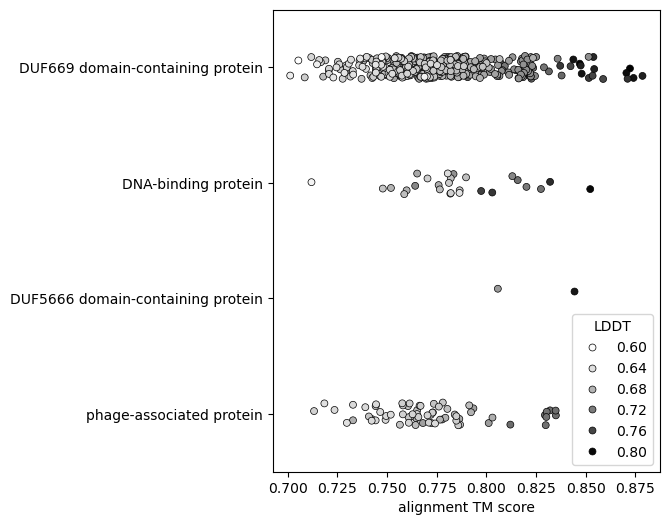

In [7]:
# It seems likely that this is some kind of single-stranded DNA-binding protein, as it clearly bears structural resemblance to DUF669. 

# https://academic.oup.com/nar/article/44/10/4551/2517025 
# The paper above specifically discusses single-stranded DNA binding (SSB) proteins in dsDNA phages.
# They suggest that DUF669 viral members represent SSBs involved in DNA replication and that both DUF669 and N4-like SSBs feature highly evolved OB-fold domains. 
# OB (oligonucleotide-binding) may not be specific to ssDNA, but this is what the author's suggest based on absence of other SSBs.

# https://www.researchsquare.com/article/rs-8337580/v1

# There are very close homologs in Mercury mini-Borgs. However, there are kind of homologs all over the place in ggKbase, including many which 
# are very clearly on bacterial contigs.

fig, ax = plt.subplots(figsize=(5, 6))

figure_df = foldseek_search_df[~foldseek_search_df.category.isin(['none', 'uncharacterized'])].copy()
figure_df = figure_df.sort_values('lddt', ascending=False).drop_duplicates('target_id') # Keep the best hit to each target. 
sns.stripplot(figure_df, y='category', x='alignment_tm_score', ax=ax, hue='lddt', palette='Grays', edgecolor='black', linewidth=0.5)
ax.set_xlabel('alignment TM score')
ax.get_legend().set_title('LDDT')
ax.set_ylabel('')
plt.show()


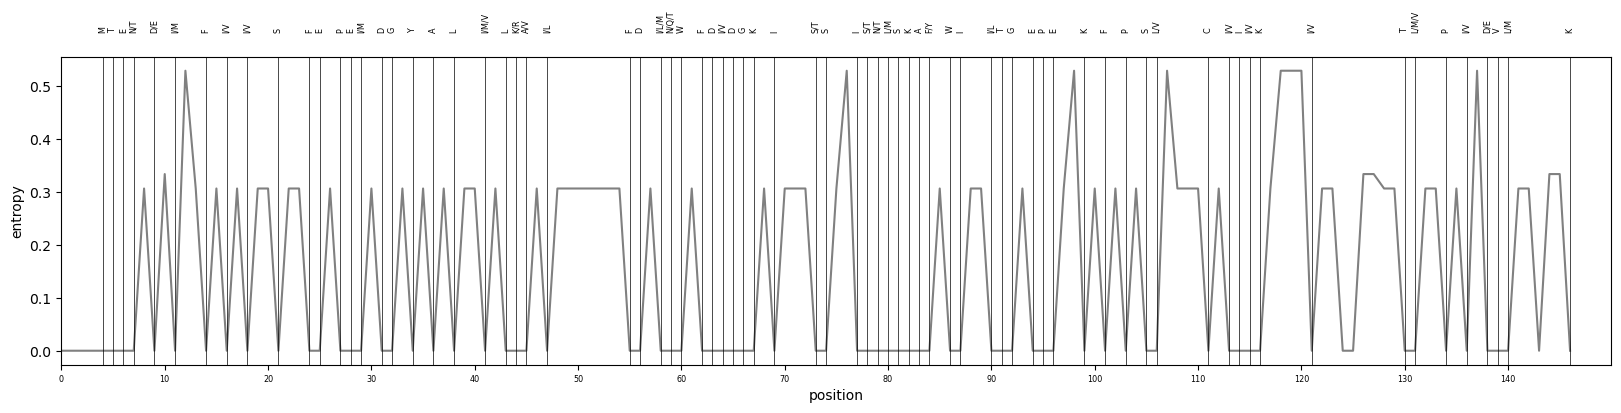

In [8]:
msa = MSAFile.from_file('../data/genes/cluster_25.afa') # Load the untrimmed alignment.
# plot_hydrophobicity(msa, x_max=70)
# msa.show()
def plot_entropy(msa:MSAFile, max_entropy=0.2, x_min=20, x_max=70, ax:plt.Axes=None, color:str='gray', alphabet:dict=None, annotate:bool=False):

    entropy = msa.get_entropy(alphabet=alphabet, max_gap_fraction=0.8)

    ax.plot(np.arange(len(entropy)), entropy, color=color)

    if annotate:
        conserved_idxs = np.where((entropy < max_entropy) & (~np.isnan(entropy)))[0] 
        # conserved_idxs = [idx for idx in conserved_idxs if (msa.gap_symbol not in msa.to_array().T[idx])] # Remove indices that look conserved but have a gap. 
        conserved_aas = [np.unique(msa.to_array().T[idx]) for idx in conserved_idxs]

        for idx, aas in zip(conserved_idxs, conserved_aas):
            if MSAFile.gap_symbol in aas:
                continue 
            
            if (idx > x_max) or (idx < x_min):
                continue
            ax.text(idx, ax.get_ylim()[-1] + 0.05, '/'.join(aas), ha='center', fontsize='xx-small', rotation=90)
            ax.axvline(idx, color='black', lw=0.5)

    x_ticks = np.arange(x_min, x_max, 10)
    ax.set_xticks(x_ticks, labels=x_ticks, fontsize='xx-small')
    ax.set_xlim(xmin=x_min, xmax=x_max)
    ax.set_ylabel('entropy')
    ax.set_xlabel('position')

x_min, x_max = 0, 150
fig, ax = plt.subplots(figsize=(20, 4))

plot_entropy(msa, ax=ax, x_min=x_min, x_max=x_max, alphabet=REDUCED_ALPHABET, annotate=True)




In [9]:
# Are there patterns in the position of GC enrichment? In other words, is GC1, GC2, or GC3 higher? This could indicate the nature of selection pressure on 
# the nucleotide sequences; there is substantially more flexibility at the third codon position compared to the first or second. 
# If the RNA structure is being selected independently of the protein, there might be a strong effect at third codon positions, because synonymous substitutions 
# there can alter RNA structure without changing the protein.

figure_df = list()
for row in genes_df.itertuples():
    codons = [row.nt_seq[i:i + 3] for i in range(0, len(row.nt_seq), 3)]
    for i, codon in enumerate(codons):
        figure_df += [{'gene_id':row.Index, 'position':j + 1, 'is_gc':nt in 'GC', 'codon_num':i + 1} for j, nt in enumerate(codon)]

figure_df = pd.DataFrame(figure_df)
figure_df = figure_df.pivot(columns='position', index=['gene_id', 'codon_num'], values='is_gc').reset_index()
figure_df = figure_df.groupby('gene_id').aggregate({1:'mean', 2:'mean', 3:'mean'})
figure_df


position,1,2,3
gene_id,,,
orfm.bz_0.1_70,0.453237,0.338129,0.266187
orfm.bz_11.1_159,0.451389,0.298611,0.250000
orfm.bz_2.1_138,0.415493,0.295775,0.190141


In [10]:
def get_random_seqs_gc_content(nt_seq, n:int=100, seed:int=42):
    '''Generates n random nucleotide sequences of the same length and GC content as the input sequence. 
    
    :param nt_seq: The nucleotide sequence to use as reference.
    :param n: The number of sequences to generate. 
    '''
    if seed is not None:
        np.random.seed(seed)

    gc_content = get_gc_content(nt_seq)
    length = len(nt_seq)
    gc_count = int(length * gc_content)

    nt_seqs = list()
    for _ in range(n):
        # Randomly select a new set of bases with each iteration. 
        bases = np.random.choice(['G', 'C'], size=gc_count, replace=True).tolist()
        bases += np.random.choice(['A', 'T'], size=length - gc_count, replace=True).tolist()
        np.random.shuffle(bases) # Modifies inplace.
        nt_seqs.append(''.join(bases))

    return nt_seqs


# AMINO_ACID_TO_CODONS_MAP = {'A':['GCU','GCC','GCA','GCG'],'R':['CGU','CGC','CGA','CGG','AGA','AGG'],'N':['AAU','AAC'],'D':['GAU','GAC'],'C':['UGU','UGC'],'E':['GAA','GAG'],'Q':['CAA','CAG'],'G':['GGU','GGC','GGA','GGG'],'H':['CAU','CAC'],'I':['AUU','AUC','AUA'],'L':['UUA','UUG','CUU','CUC','CUA','CUG'],'K':['AAA','AAG'],'M':['AUG'],'F':['UUU','UUC'],'P':['CCU','CCC','CCA','CCG'],'S':['UCU','UCC','UCA','UCG','AGU','AGC'],'T':['ACU','ACC','ACA','ACG'],'W':['UGG'],'Y':['UAU','UAC'],'V':['GUU','GUC','GUA','GUG'],'*':['UAA','UAG','UGA']}
AMINO_ACID_TO_CODONS_MAP = {'A':['GCT','GCC','GCA','GCG'],'R':['CGT','CGC','CGA','CGG','AGA','AGG'],'N':['AAT','AAC'],'D':['GAT','GAC'],'C':['TGT','TGC'],'E':['GAA','GAG'],'Q':['CAA','CAG'],'G':['GGT','GGC','GGA','GGG'],'H':['CAT','CAC'],'I':['ATT','ATC','ATA'],'L':['TTA','TTG','CTT','CTC','CTA','CTG'],'K':['AAA','AAG'],'M':['ATG'],'F':['TTT','TTC'],'P':['CCT','CCC','CCA','CCG'],'S':['TCT','TCC','TCA','TCG','AGT','AGC'],'T':['ACT','ACC','ACA','ACG'],'W':['TGG'],'Y':['TAT','TAC'],'V':['GTT','GTC','GTA','GTG'],'*':['TAA','TAG','TGA']}
CODON_TO_AMINO_ACID_MAP = {codon:aa for aa, codons in AMINO_ACID_TO_CODONS_MAP.items() for codon in codons}

get_codons = lambda nt_seq : [nt_seq[i:i + 3] for i in range(0, len(nt_seq), 3)]

def get_codon_usage(nt_seqs):
    '''Get the codon usage frequencies for a particular set of genes.'''
    counts = {codon:0 for codon in CODON_TO_AMINO_ACID_MAP.keys()}
    for nt_seq in nt_seqs:
        for codon, n in zip(*np.unique(get_codons(nt_seq), return_counts=True)):
            counts[str(codon)] += n

    df = pd.DataFrame.from_dict(counts, orient='index', columns=['count']).reset_index(names='codon')
    df['amino_acid'] = df.codon.map(CODON_TO_AMINO_ACID_MAP)
    df = df[df.amino_acid != '*'].copy()
    # df['frequency'] = df.groupby('amino_acid').transform(lambda df :print(df))
    df['total'] = df.groupby('amino_acid')['count'].transform('sum')
    df['frequency'] = df['count'] / df['total']
    df = df.fillna(0)
    return df.set_index('codon').frequency.to_dict()



def get_random_seqs_amino_acids(seq, n:int=1000, codon_usage:dict=dict(), seed:int=42):
    '''Generates n random nucleotide sequences constrained by the given amino acid sequence. If a codon_usage
    dictionary is provided, then codons are selected with a probability concordant with the background.
    '''
    if seed is not None:
        np.random.seed(seed)

    seqs = list()
    for aa in seq: # Iterate over each amino acid and store possible codons in a (len(seq), n)-dimensional array.
        codons = AMINO_ACID_TO_CODONS_MAP[aa] # Get all possible codons for the amino acid.
        frequencies = [codon_usage.get(codon, 1/len(codons)) for codon in codons]
        seqs.append(np.random.choice(codons, p=frequencies, size=n, replace=True))
    seqs = np.array(seqs).T
    seqs = [''.join(seq) for seq in seqs]
    return seqs


In [11]:
n = 500
genome_id = 'bz_0'
gene_id = genes_df[genes_df.genome_id == genome_id].index[0]
nt_seq, seq = genes_df.loc[gene_id].nt_seq, genes_df.loc[gene_id].seq
codon_usage = get_codon_usage(FASTAFile.from_file(f'../data/genes/prodigal/{genome_id}.fna').seqs) # Just use the Prodigal genes to estimate codon usage.

RNAFOLD_DIR = '../data/genes/rnafold/'
RNAFOLD_CONTROL_DIR = os.path.join(RNAFOLD_DIR, 'control', genome_id)
os.makedirs(RNAFOLD_CONTROL_DIR, exist_ok=True) # Make a directory to store the control sequences. 


if os.path.exists(f'analysis-1-cluster_25-rnafold_{genome_id}.csv'):
    rnafold_df = pd.read_csv(f'analysis-1-cluster_20-rnafold_{genome_id}.csv', index_col=0)
else:

    rnafold_df = list()
    rnafold_df += [{'gc_content_control':True, 'codon_usage_control':False, 'amino_acid_control':False, 'nt_seq':nt_seq} for nt_seq in get_random_seqs_gc_content(nt_seq, n=n)]
    rnafold_df += [{'gc_content_control':False, 'codon_usage_control':False, 'amino_acid_control':True, 'nt_seq':nt_seq} for nt_seq in get_random_seqs_amino_acids(seq, n=n)]
    rnafold_df += [{'gc_content_control':False, 'codon_usage_control':True, 'amino_acid_control':True, 'nt_seq':nt_seq} for nt_seq in get_random_seqs_amino_acids(seq, n=n, codon_usage=codon_usage)]
    rnafold_df = pd.DataFrame(rnafold_df).assign(control=True)

    df = list()
    for row in tqdm(list(rnafold_df.itertuples()), desc='Running RNAFold analysis on random RNA sequences.'):
        output_path = os.path.abspath(os.path.join(RNAFOLD_CONTROL_DIR, f'{row.Index}.out'))

        if not os.path.exists(output_path):
            input = f'>{row.Index}\n{row.nt_seq}\n'
            with open(output_path, 'w') as f: # Run RNAFold, suppressing PS output. 
                subprocess.run(['RNAfold', '-p',  '--noPS', '-d2'], input=input, text=True, stdout=f, check=True, cwd=RNAFOLD_CONTROL_DIR)

        df += [RNAFoldOutput(os.path.join(RNAFOLD_CONTROL_DIR, str(row.Index))).get_data()]

    rnafold_df = pd.concat([rnafold_df, pd.DataFrame(df, index=rnafold_df.index)], axis=1) # Add the RNAFold output to the DataFrame.
    rnafold_df.to_csv(f'analysis-1-cluster_25-rnafold_{genome_id}.csv', index=True)

    # shutil.rmtree(RNAFOLD_CONTROL_DIR)
    

for row in tqdm(list(genes_df.itertuples()), desc='Running RNAFold analysis.'):
    name = f'{row.Index}'
    output_path = os.path.abspath(os.path.join(RNAFOLD_DIR, name) + '.out')

    # if os.path.exists(output_path):
    #     continue

    with open(output_path, 'w') as f: 
        subprocess.run(['RNAfold', '-p', '-d2'], input=f'>{name}\n{row.nt_seq}\n', text=True, stdout=f, check=True, cwd=RNAFOLD_DIR)



Running RNAFold analysis.: 100%|██████████| 3/3 [00:01<00:00,  2.59it/s]


In [12]:
genes_df.seq.apply(len)

gene_id
orfm.bz_0.1_70      139
orfm.bz_2.1_138     142
orfm.bz_11.1_159    144
Name: seq, dtype: int64

In [13]:
get_pairwise_alignments(genes_df.seq, normalize=False, metric='aligned')

gene_id,orfm.bz_0.1_70,orfm.bz_2.1_138,orfm.bz_11.1_159
gene_id,,,
orfm.bz_0.1_70,0.0,138.0,136.0
orfm.bz_2.1_138,138.0,0.0,139.0
orfm.bz_11.1_159,136.0,139.0,0.0


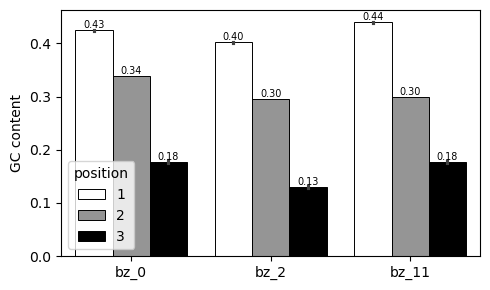

In [14]:
def get_gc_content_by_position(genes_df:pd.DataFrame):
    ''''''
    df = list()
    for row in genes_df.itertuples():
        codons = [row.nt_seq[i:i + 3] for i in range(0, len(row.nt_seq), 3)]
        gc_counts = np.zeros(3)
        for codon in codons:
            gc_counts += np.isin(list(codon), ['G', 'C']).astype(int)
        df += [{'gene_id':row.Index, 'position':i + 1, 'gc_count':count, 'num_codons':len(codons)} for i, count in enumerate(gc_counts)]
    return pd.DataFrame(df) 


figure_df = list()

for row in genes_df.itertuples():
    codon_usage = get_codon_usage(FASTAFile.from_file(f'../data/genes/prodigal/{row.genome_id}.fna').seqs) # Just use the Prodigal genes to estimate codon usage.

    figure_df_ = get_gc_content_by_position(pd.DataFrame({'nt_seq':get_random_seqs_amino_acids(row.seq, n=500, codon_usage=codon_usage)}))
    figure_df_['genome_id'] = row.genome_id 
    figure_df.append(figure_df_)

figure_df = pd.concat(figure_df)
figure_df['gc_content'] = figure_df.gc_count / figure_df.num_codons

fig, ax = plt.subplots(figsize=(5, 3))
sns.barplot(figure_df, x='genome_id', y='gc_content', hue='position', palette='Grays', lw=0.7, edgecolor='black')
ax.set_ylabel('GC content')

for containers in ax.containers:
    ax.bar_label(containers, fmt='%.2f', fontsize='x-small')

ax.set_xlabel('')
fig.tight_layout()
plt.show()


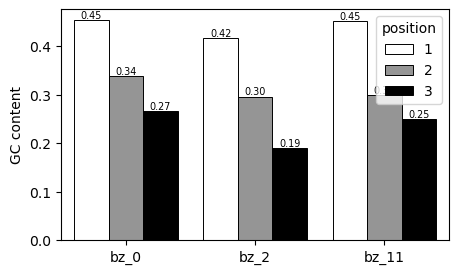

In [15]:
# Are there patterns in the position of GC enrichment? In other words, is GC1, GC2, or GC3 higher? This could indicate the nature of selection pressure on 
# the nucleotide sequencs; there is substantially more flexibility at the third codon position compared to the first or second. 
# If the RNA structure is being selected independently of the protein, there might be a strong effect at third codon positions, because synonymous substitutions 
# there can alter RNA structure without changing the protein.


figure_df = get_gc_content_by_position(genes_df)
figure_df['gc_content'] = figure_df.gc_count / figure_df.num_codons
figure_df['genome_id'] = [get_genome_id(gene_id) for gene_id in figure_df.gene_id]

fig, ax = plt.subplots(figsize=(5, 3))
sns.barplot(figure_df, x='genome_id', y='gc_content', hue='position', palette='Grays', lw=0.7, edgecolor='black')
ax.set_ylabel('GC content')

for containers in ax.containers:
    ax.bar_label(containers, fmt='%.2f', fontsize='x-small')
    
ax.set_xlabel('')
plt.show()

# The pattern in GC content positions doesn't seem to make a lot of sense, as I would expect GC1 and GC2 to be similar. Probably the best thing to do
# is compute the positional GC content for sequences  with the same amino acid sequence constraints. Maybe this odd pattern is just a result of amino acid-level selction.

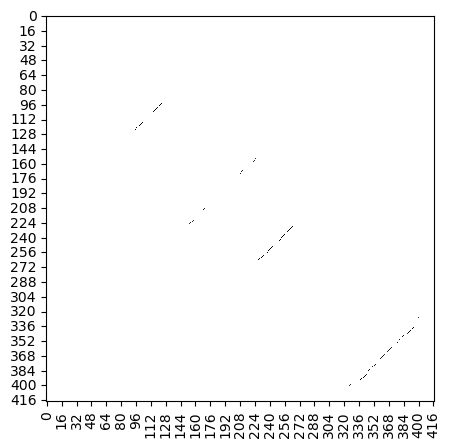

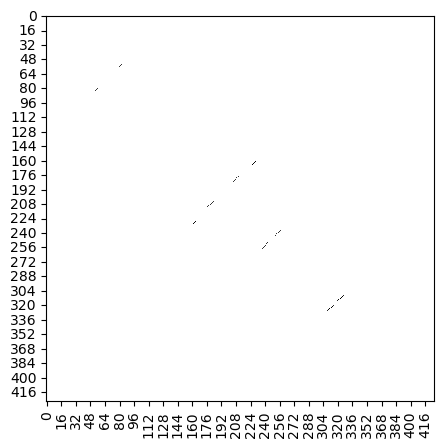

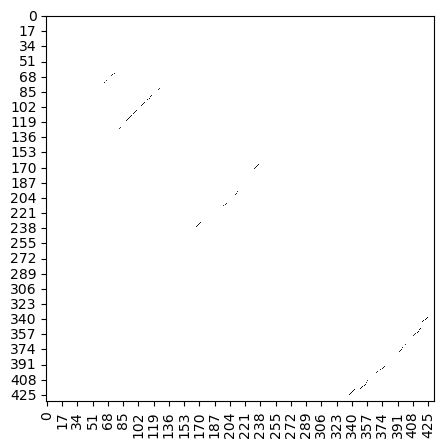

In [16]:
for gene_id in genes_df.index:
    path = os.path.join(RNAFOLD_DIR, gene_id)
    RNAFoldOutput(path).dotplot()

In [17]:
genome_ids = ['bz_0', 'bz_2', 'bz_11']

rnafold_df = [pd.read_csv(f'analysis-1-cluster_25-rnafold_{genome_id}.csv', index_col=0).assign(genome_id=genome_id, control=True) for genome_id in genome_ids]
rnafold_df += [pd.DataFrame([RNAFoldOutput(os.path.join(RNAFOLD_DIR, name)).get_data(nt_seq=True) for name in genes_df.index]).assign(control=False).set_index('name')]
rnafold_df = pd.concat(rnafold_df).fillna(False)

rnafold_df['length'] = rnafold_df.nt_seq.apply(len)
rnafold_df['ensemble_free_energy_normalized'] = rnafold_df.ensemble_free_energy / rnafold_df.length
rnafold_df['mfe_free_energy_normalized'] = rnafold_df.mfe_free_energy / rnafold_df.length
rnafold_df['gc_content'] = rnafold_df.nt_seq.apply(get_gc_content)

for gene_id in genes_df.index:
    rnafold_df.loc[gene_id, 'genome_id'] = get_genome_id(gene_id)

bz_0 p=0.000 (n=500, delta=0.062)
bz_11 p=0.028 (n=500, delta=0.024)
bz_2 p=0.122 (n=500, delta=0.014)


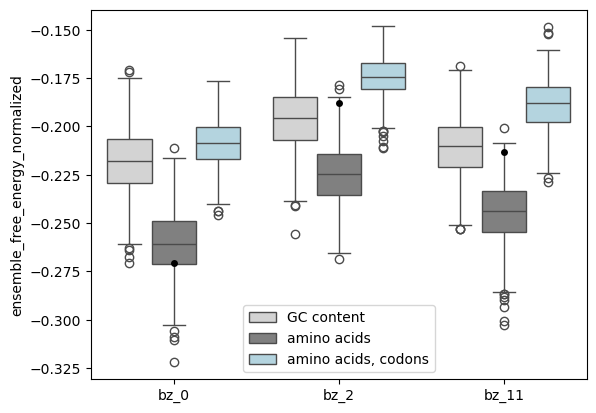

In [18]:


figure_df = rnafold_df[rnafold_df.control].copy() # Get the null distributions.

fig, ax = plt.subplots()

metric = 'ensemble_free_energy_normalized'
# metric = 'mfe_free_energy_normalized'
# metric = 'ensemble_diversity'
# metric = 'gc_content'

categories = dict()
categories['amino acids'] = figure_df.amino_acid_control & ~figure_df.codon_usage_control
categories['amino acids, codons'] = figure_df.amino_acid_control & figure_df.codon_usage_control
categories['GC content'] = figure_df.gc_content_control.astype(bool) # Sequences explicitly controlling for GC content with no other constraints.

figure_df['category'] = np.select(*list(zip(*categories.items()))[::-1], default='none')

palette = dict()
palette['amino acids'] = 'gray'
palette['amino acids, codons'] = 'lightblue'
palette['amino acids, GC content'] = 'steelblue'
palette['GC content'] = 'lightgray'


sns.boxplot(figure_df, x='genome_id', y=metric, hue='category', palette=palette)

figure_df = rnafold_df[(~rnafold_df.control)].loc[genes_df.index].copy()
sns.stripplot(figure_df, x='genome_id', y=metric, color='black')

for genome_id, df in figure_df.groupby('genome_id'):
    value = getattr(df.iloc[0], metric)
    # null = rnafold_df[rnafold_df.control & rnafold_df.gc_content_control & (rnafold_df.genome_id == genome_id)][metric].values 
    null = rnafold_df[rnafold_df.control & rnafold_df.codon_usage_control & (rnafold_df.genome_id == genome_id)][metric].values 
    print(f'{genome_id} p={(null < value).mean():.3f} (n={len(null)}, delta={null.mean() - value:.3f})')


ax.set_xlabel('')
plt.show()

# (1) The difference in free energy relative to the null model is significant in all cases. 
# (2) In general, the codon usage in the organism results in slightly higher free energy than if GC content was fixed. Although the
#       particularly interesting that the free energy is also substantially lower than the GC content-controlled null in bz_0 and bz_11.


In [ ]:
# foldseek_search_df = pd.concat([pd.read_csv(path, sep='\t', names=FOLDSEEK_FIELDS).assign(path=path) for path in glob.glob('../data/genes/foldseek/genes*')])

# filters = dict()
# filters['low_tm_score'] = foldseek_search_df.alignment_tm_score < 0.5
# filters['short_alignment'] = foldseek_search_df.alignment_length < 50

# foldseek_search_df = apply_filters(filters, foldseek_search_df)

In [19]:

# fig, ax = plt.subplots(figsize=(6, 3))

# figure_df = rnafold_df.copy()
# # Free energy depends on length, so should to normalize by length if comparing sequences of differeing length.
# figure_df['length'] = figure_df.nt_seq.apply(len)
# for col in figure_df.columns:
#     if 'free_energy' in col:
#         figure_df[col + '_normalized'] = figure_df[col] / figure_df.length
# figure_df['gc_content'] = figure_df.nt_seq.apply(get_gc_content)
# # Update GC content control status if the synonymous sequences are reasonably close to the Betazoid gene.
# delta = 0.05
# figure_df['gc_content_control'] = (figure_df.gc_content > (get_gc_content(nt_seq) - delta)) & (figure_df.gc_content < (get_gc_content(nt_seq) + delta))

# metric = 'ensemble_free_energy_normalized'
# # metric = 'mfe_free_energy_normalized'
# # metric = 'mfe_free_energy' # I think I can avoid normalizing by sequence length, because all have the same length.
# # metric = 'gc_content'
# # metric = 'ensemble_diversity'
# # metric = 'length'
# # metric = 'mfe_frequency_in_ensemble'
# # metric = 'gc_content'

# filters = dict()
# filters['amino acids'] = figure_df.control & figure_df.amino_acid_control & ~figure_df.codon_usage_control
# filters['amino acids, codons'] = figure_df.control & figure_df.amino_acid_control & figure_df.codon_usage_control
# filters['amino acids, GC content'] = figure_df.control & figure_df.amino_acid_control & ~figure_df.codon_usage_control & figure_df.gc_content_control # Sequences which did not have specifically-selected codons, but happen to have the correct GC content.
# filters['GC content'] = figure_df.control & ~figure_df.amino_acid_control & ~figure_df.codon_usage_control & figure_df.gc_content # Sequences explicitly controlling for GC content with no other constraints.

# palette = dict()
# palette['amino acids'] = 'gray'
# palette['amino acids, codons'] = 'lightblue'
# palette['amino acids, GC content'] = 'steelblue'
# palette['GC content'] = 'lightgray'

# x_ticks = list()
# for label, filter_ in filters.items():
#     if ((metric == 'gc_content') and (label == 'GC content')) or (filter_.sum() <= 1):
#         continue
#     print(f'Number of sequences in category {label}:', filter_.sum())
#     sns.kdeplot(figure_df[filter_], x=metric, color=palette[label], label=label, ax=ax)
#     x_ticks += [np.round(figure_df[filter_][metric].mean(), 2)]
# # x_ticks = np.unique(sorted(x_ticks + ax.get_xticks().tolist()))

# ax.axvline(figure_df.loc[gene_id][metric], ls='--', color='black')

# x_ticks = sorted(x_ticks + [np.round(figure_df.loc[gene_id][metric], 2)])
# ax.set_xticks(x_ticks, labels=x_ticks, rotation=90)

# ax.legend()
# ax.set_title(gene_id)
# ax.set_ylabel('density')
# plt.show()

# # Trends in GC content:
# #   (1) When only controlling for amino acids, the GC content of the gene is much higher than observed (~45%). 
# #   (2) Using the observed codon frequencies for the rest of the genome, the GC content is higher than expected, though only about 2% (bz_2), 4% (bz_0), and 2% (bz_11).
# # Overall, it seems as though there may be some pressure for selecting high-GC sequences, though the actual magnitude of the GC content difference is fairly small. 

# # Trends in free energy (ensemble, length-normalized):
# #   (1) The free energy is about what would be expected of a random sequence with the same GC content.
# #   (2) The free energy is about what would be expected of a random sequence with the same GC content.




In [20]:
# Make an AlphaFold input file for the web server for some exploratory analysis on the processed proteins. These were obtained by:
#   (1) N-terminally extending some of the cluster_25 proteins  (those around 80 amino acids in length) to around 95 amino acids.
#   (2) De-replicating the dataset, as some of the sequences differed only in the N-terminal region. 
#   (3) For those with strong signal peptide predictions (all of those with the N-terminal region), obtain the processed sequence using 
#       SignalP, i.e. the protein with the signal peptide cleaved. 


# seq_col = 'seq_processed'
# num_subunits = 2

# inputs = list()
# for path in msa_paths:
#     with open(path, 'r') as f:
#         msa = f.read()
#         print(f'Number of sequences in {path}:', msa.count('>'))

#         gene_id = os.path.basename(path).replace('.a3m', '')
#         input = AlphaFoldInputFile(name=f'{get_genome_id(gene_id)}_cluster_25_{n}mer_processed', num_seeds=1, dialect='alphafoldserver')
#         input.add_seq(database_df.loc[gene_id, seq_col], unpaired_msa=msa, paired_msa="", n=num_subunits)
#         inputs.append(input)

# inputs = [input.get_info() for input in inputs]
# with open('/home/prichter/Downloads/cluster_25.json', 'w') as f:
#     json.dump(inputs, f)


In [21]:
# for path in glob.glob('../data/genes/alphafold/server/*'):
#     if 'cluster_20_2mer' in path:
#         print(path)
#         output = AlphaFoldServerOutput(path)
#         contact_probs = output.get_contact_probs(best_model=True)
#         paes = output.get_paes(best_model=True)

# contact_probs = contact_probs[:70, -70:]
# sns.kdeplot(contact_probs.ravel())
# row_idxs, col_idxs = np.where(contact_probs > 0.5)
# contact_probs



In [22]:
# # Two of the three original cluster_20 proteins have a weak annotation for a prokaryotic lipoprotein attachment site (from InterProScan). 
# # Based on this result, I ran SignalP on each of the original cluster_20 proteins, as well as the ggKbase BLAST hits.

# SIGNALP_FIELDS = ['gene_id', 'prediction', 'other', 'sp_sec_spi', 'lipo_sec_spii', 'tat_tat_spi', 'tatlipo_tat_spii)', 'pilin_sec_spiii', 'cleavage_site_position']
# signalp_df = pd.read_csv('../data/genes/signalp/cluster_20.txt', sep='\t', comment='#', names=SIGNALP_FIELDS)

# if 'prediction' not in ggkbase_df.columns:
#     ggkbase_df = ggkbase_df.merge(signalp_df, on='gene_id', how='left')

# ggkbase_df[['gene_id', 'prediction', 'length', 'sp_sec_spi']]

In [23]:
# for row in genes_df.itertuples():
#     print(f'>{row.Index}')
#     print(row.seq)

In [24]:
# # SR-VP_9_9_2021_59_4A_0_85m_scaffold_34976_2 is Betazoid.
# # Dalian_Groundwater_SRR22387926_scaffold_135972_3 is Betazoid.
# # SR-VP_07_25_2022_A1_70cm_scaffold_29863_3 is a Betazoid.

# # Based on the GC content, it seems as though some of the hits might belong to Borgs?

# # I wonder if the short sequences have mispredicted starts?


# GGKBASE_DIR = '../data/genes/ggkbase/'
# gene_ids = ['Dalian_Groundwater_SRR22387926_scaffold_135972_3', 'SR-VP_07_25_2022_A1_70cm_scaffold_29863_3']

# ggkbase_df = pd.concat([FASTAFile.from_file(os.path.join(GGKBASE_DIR, f'{gene_id}.faa')).to_df() for gene_id in genes_df.index])
# ggkbase_df.index = [gene_id.split('|')[0] for gene_id in ggkbase_df.index] # Clean up the ggKbase gene IDs.
# ggkbase_df = ggkbase_df[~ggkbase_df.index.duplicated(keep='first')].copy()

# ggkbase_df['contig_id'] = ['_'.join(gene_id.split('_')[:-1]) for gene_id in ggkbase_df.index]
# ggkbase_df['start'] = ggkbase_df.description.apply(lambda description : int(description.split('#')[1].strip())) - 1 # Convert to zero-indexed for my sanity. 
# ggkbase_df['stop'] = ggkbase_df.description.apply(lambda description : int(description.split('#')[2].strip()))
# ggkbase_df['strand'] = ggkbase_df.description.apply(lambda description : int(description.split('#')[3].strip()))
# ggkbase_df = ggkbase_df.loc[gene_ids].copy()
# ggkbase_df['contig'] = ggkbase_df.contig_id.apply(lambda contig_id : FASTAFile.from_file(os.path.join(GGKBASE_DIR, f'{contig_id}.fasta')).seqs[0])


# for row in ggkbase_df.itertuples():
#     if row.strand == -1:
#         contig_length = len(row.contig)
#         ggkbase_df.loc[row.Index, 'strand'] = 1
#         ggkbase_df.loc[row.Index, 'start'] = contig_length - row.stop
#         ggkbase_df.loc[row.Index, 'stop'] = contig_length - row.start
#         ggkbase_df.loc[row.Index, 'contig'] = reverse_complement(row.contig)

# ggkbase_df['nt_seq'] = ggkbase_df.apply(lambda row : row.contig[row.start:row.stop], axis=1)
# ggkbase_df['start_codon'] =  ggkbase_df.apply(lambda row : row.contig[row.start:row.start + 3], axis=1)
# ggkbase_df['stop_codon'] =  ggkbase_df.apply(lambda row : row.contig[row.stop - 3:row.stop], axis=1)

# translate = lambda nt_seq : str(Seq(nt_seq).translate(to_stop=False))

# for row in ggkbase_df.itertuples():
#     nt_seq = row.contig[:row.start] # Get the sequence before the start codon. 
#     nt_seq = nt_seq[len(nt_seq) % 3:] # Make sure it's a length divisible by three; shift start position so the sequence is in-frame.
#     codons = np.array([nt_seq[i:i+3] for i in range(0, len(nt_seq), 3)])
#     stop_codon_idx = np.where(np.isin(codons, STOP_CODONS))[0].max()
    
#     nt_seq = ''.join(codons[-30:])
#     print(nt_seq)
#     print(translate(nt_seq), translate(row.contig[row.start:row.stop]))



In [25]:
# GGKBASE_DIR = '../data/genes/ggkbase/'

# query_gene_ids = genes_df.index.tolist()

# paths = [os.path.join('../data/genes', f'{gene_id}.faa') for gene_id in genes_df.index]

# database_df = [genes_df[['seq']].copy()]
# database_df += [FASTAFile.from_file(os.path.join(GGKBASE_DIR, f'{gene_id}.faa')).to_df()[['seq']] for gene_id in genes_df.index]
# database_df = pd.concat(database_df)
# database_df = database_df[database_df.seq.apply(len) < 110].copy() # These all seem to be false positives.
# database_df = database_df.drop_duplicates('seq')
# database_df.index = [gene_id.split('|')[0] for gene_id in database_df.index] # Clean up the ggKbase gene IDs.
# database_df = database_df[database_df.index != 'SR2-18-Sp2_coassembly_scaffold_597830_2'].copy() # Don't really trust this hit. 

# assert np.all(np.isin(query_gene_ids, database_df.index)), 'Some of the query sequences are missing from the database.'
# FASTAFile.from_df(database_df).write('../data/genes/mmseqs/cluster_20_database.faa')

# params = dict()
# # params['min_seq_identity'] = 0.99
# # params['num_iterations'] = 3

# msa_paths = msa_main('../data/genes/mmseqs/cluster_20_database.faa', query_gene_ids=query_gene_ids, database_dir='../data/genes/mmseqs/db/', fmt='a3m', name=f'cluster_20', output_dir='../data/genes/mmseqs', **params)

In [26]:
for row in database_df.itertuples():
    print(f'>{row.Index}')
    print(row.seq)

NameError: name 'database_df' is not defined

In [ ]:
msa = MSAFile.from_file('../data/genes/cluster_25.afa')
msa.show()


NameError: name 'MSAFile' is not defined

In [ ]:
tmhmm_file = TMHMMFile.from_file('../data/genes/tmhmm/genes.txt')
tmhmm_df = tmhmm_file.to_df()
# tmhmm_df = tmhmm_df[tmhmm_df.]

INTERPROSCAN_FIELDS = ['gene_id', 'checksum', 'length', 'analysis', 'signature_accession', 'signature_description', 'annotation_start','annotation_stop', 'annotation_e_value', 'annotation_status', 'date', 'interpro_accession', 'interpro_description', 'go_terms', 'pathways']
annot_df = pd.read_csv('../data/genes/interproscan/genes.tsv', sep='\t', header=None, names=INTERPROSCAN_FIELDS)
annot_df = annot_df[annot_df.gene_id.isin(genes_df.index)].copy()

In [ ]:
genes_df = pd.read_csv('../data/genes/genes.csv', index_col=0)
genes_df['cluster_id'] = genes_df.index.map(json.load(open('../data/genes/clusters.json', 'r')))
genes_df[genes_df.cluster_id == 1].strand.value_counts()

strand
-    11
Name: count, dtype: int64

In [ ]:
gene

NameError: name 'gene' is not defined